In [1]:
!pip install wfdb numpy matplotlib neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
#importing libraries
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

In [6]:
# Create a folder to store record
!mkdir mitdb

# Download record 100 files: .dat, .hea, .atr
!wget -P mitdb https://physionet.org/files/mitdb/1.0.0/100.dat
!wget -P mitdb https://physionet.org/files/mitdb/1.0.0/100.hea
!wget -P mitdb https://physionet.org/files/mitdb/1.0.0/100.atr

--2026-03-31 13:31:01--  https://physionet.org/files/mitdb/1.0.0/100.dat
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1950000 (1.9M) [application/octet-stream]
Saving to: ‘mitdb/100.dat’

100.dat             100%[===================>]   1.86M   127KB/s    in 13s     

2026-03-31 13:31:15 (142 KB/s) - ‘mitdb/100.dat’ saved [1950000/1950000]

--2026-03-31 13:31:15--  https://physionet.org/files/mitdb/1.0.0/100.hea
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 143 [text/plain]
Saving to: ‘mitdb/100.hea’

100.hea             100%[===================>]     143  --.-KB/s    in 0s      

2026-03-31 13:31:15 (36.8 MB/s) - ‘mitdb/100.hea’ saved [143/143]

--2026-03-31 13:31:15--  https://physionet.org/files/mitdb/1.0.0/1

In [3]:
import wfdb

# Load the record from local files
record = wfdb.rdrecord('mitdb/100')
annotation = wfdb.rdann('mitdb/100', 'atr')

# Check basic info
print("Sampling frequency:", record.fs)
print("Channels:", record.sig_name)
print("Signal shape:", record.p_signal.shape)

Sampling frequency: 360
Channels: ['MLII', 'V5']
Signal shape: (650000, 2)


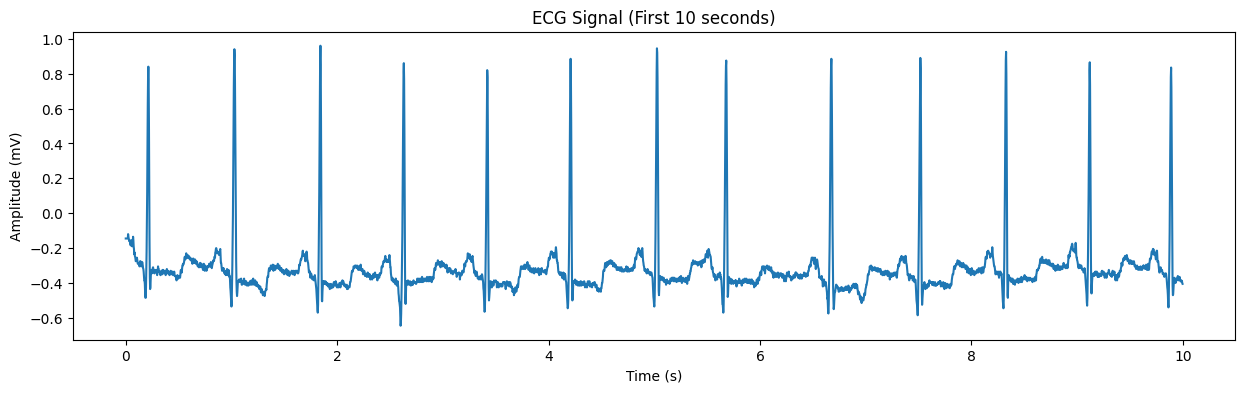

In [5]:
#plotting the raw ECG
import matplotlib.pyplot as plt
import numpy as np

# Extract MLII channel (standard ECG)
ecg_signal = record.p_signal[:, 0]
fs = record.fs  # sampling frequency
time = np.arange(len(ecg_signal)) / fs  # time in seconds

# Plot first 10 seconds of ECG
plt.figure(figsize=(15,4))
plt.plot(time[:fs*10], ecg_signal[:fs*10])
plt.title("ECG Signal (First 10 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.show()

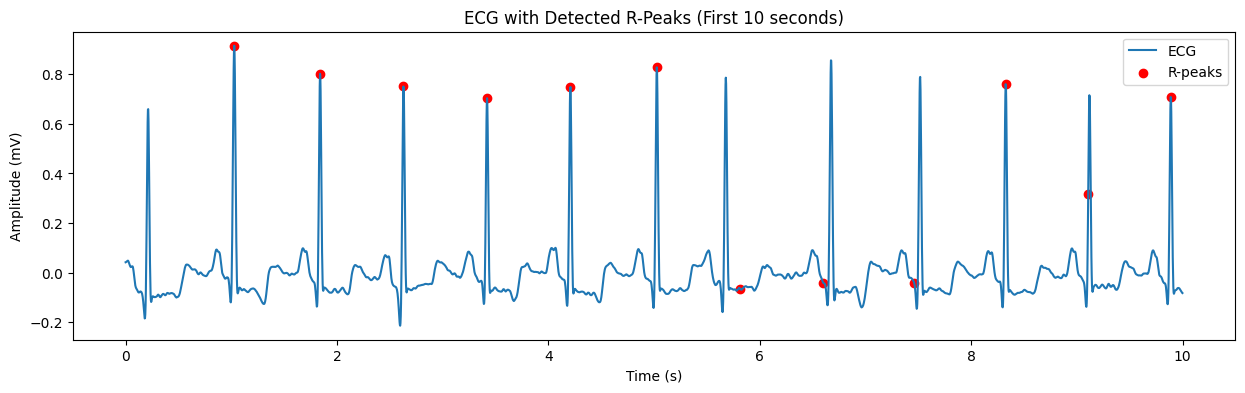

In [6]:
#detecting the R peaks with neurokit2
import neurokit2 as nk

# Cleaning the ECG signal
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs)

# Processing ECG to detect R-peaks
signals, info = nk.ecg_process(ecg_cleaned, sampling_rate=fs)
r_peaks = info['ECG_R_Peaks']

# Plotting ECG with R-peaks
plt.figure(figsize=(15,4))
plt.plot(time[:fs*10], ecg_cleaned[:fs*10], label='ECG')
plt.scatter([time[i] for i in r_peaks if i < fs*10],
            [ecg_cleaned[i] for i in r_peaks if i < fs*10],
            color='red', label='R-peaks')
plt.title("ECG with Detected R-Peaks (First 10 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

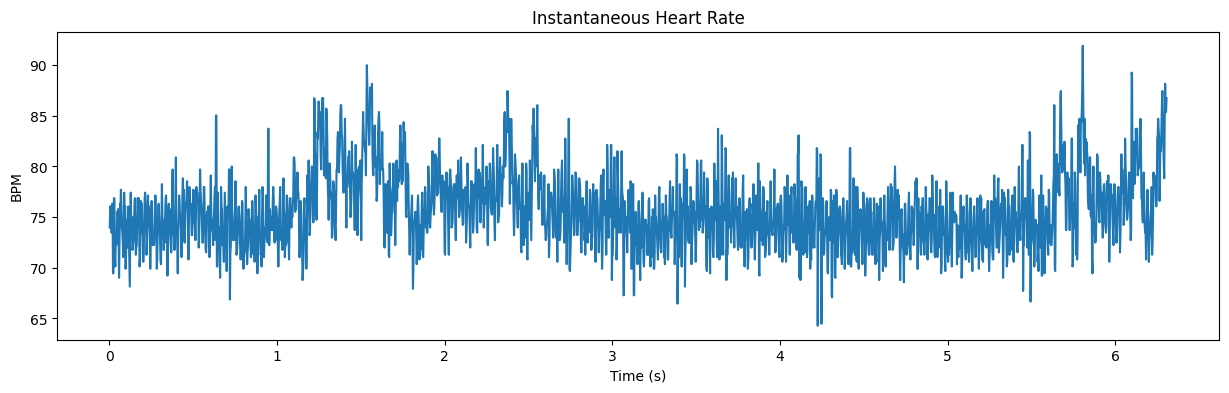

Average Heart Rate: 75.68 BPM


In [7]:
# Calculate R-R intervals in seconds
rr_intervals = np.diff(r_peaks) / fs

# Instantaneous heart rate (BPM)
heart_rate = 60 / rr_intervals

# Plot heart rate over time
plt.figure(figsize=(15,4))
plt.plot(time[1:len(heart_rate)+1], heart_rate)
plt.title("Instantaneous Heart Rate")
plt.xlabel("Time (s)")
plt.ylabel("BPM")
plt.show()

# Print average heart rate
print("Average Heart Rate:", round(np.mean(heart_rate), 2), "BPM")